# Model Training

## 1.1 Import Data and Required Packages
Importing Pandas, NumPy, Matplotlib, Seaborn, and Warnings Library

In [8]:
# Basic import
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import janitor

# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

### Import the CSV Data as Pandas Dataframe 

In [10]:
df = pd.read_csv('data/StudentsPerformance.csv')
df = df.clean_names()
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Prepare the X and Y variables

In this runthrough, we will predict math_score using all other features as predictors

In [25]:
# Define target variable and features
X = df.drop(columns=['math_score'])

In [26]:
y = df['math_score']

In [27]:
# Create column transformer with 3 types of transformers
num_features = X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ('OneHotEncoder', oh_transformer, cat_features),
        ('StandardScaler', numeric_transformer, num_features),
    ]
)

/var/folders/4m/lfd577n12v14ccpl791jzm940000gn/T/ipykernel_53580/4213249561.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include='object').columns


In [ ]:
X = preprocessor.fit_transform(X)
X.shape

In [31]:
# Separate dataframe into train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, X_test.shape

((800, 19), (200, 19))

### Create an Evaluate Function to give all metrics after model Training

In [33]:
# Create an evaluate function to give all metrics after model training
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    r2_square = r2_score(true, predicted)
    return mae, mse, r2_square

In [37]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "KNN Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBoost Regressor": XGBRegressor(),
    "CatBoost Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate train and test dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(f"{list(models.keys())[i]} Train MAE: {model_train_mae:.2f}")
    model_list.append(list(models.keys())[i])

    print('Model performance for training set')
    print('    Root Mean Squared Error: {:.4f}'.format(model_train_rmse))
    print('    Mean Absolute Error: {:.4f}'.format(model_train_mae))
    print('    R2 Score: {:.4f}'.format(model_train_r2))
    print('-' * 35)
    print('Model performance for test set')
    print('    Root Mean Squared Error: {:.4f}'.format(model_test_rmse))
    print('    Mean Absolute Error: {:.4f}'.format(model_test_mae))
    print('    R2 Score: {:.4f}'.format(model_test_r2))
    r2_list.append(model_test_r2)

    print('=' * 35)
    print('\n')



Linear Regression Train MAE: 4.27
Model performance for training set
    Root Mean Squared Error: 28.3349
    Mean Absolute Error: 4.2667
    R2 Score: 0.8743
-----------------------------------
Model performance for test set
    Root Mean Squared Error: 29.0952
    Mean Absolute Error: 4.2148
    R2 Score: 0.8804


Lasso Train MAE: 5.21
Model performance for training set
    Root Mean Squared Error: 43.4784
    Mean Absolute Error: 5.2063
    R2 Score: 0.8071
-----------------------------------
Model performance for test set
    Root Mean Squared Error: 42.5064
    Mean Absolute Error: 5.1579
    R2 Score: 0.8253


Ridge Train MAE: 4.26
Model performance for training set
    Root Mean Squared Error: 28.3378
    Mean Absolute Error: 4.2650
    R2 Score: 0.8743
-----------------------------------
Model performance for test set
    Root Mean Squared Error: 29.0563
    Mean Absolute Error: 4.2111
    R2 Score: 0.8806


KNN Regressor Train MAE: 4.53
Model performance for training set
    R

### Results

In [38]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by='R2_Score', ascending=False)

,Model Name,R2_Score
2,Ridge,0.880593
0,Linear Regression,0.880433
5,Random Forest Regressor,0.857286
7,CatBoost Regressor,0.851632
8,AdaBoost Regressor,0.848045
6,XGBoost Regressor,0.827797
1,Lasso,0.825320
3,KNN Regressor,0.783681
4,Decision Tree,0.740423


## Linear Regression

In [39]:
lin_model = LinearRegression(fit_intercept = True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print("Accuracy of the model is {:.2f}%".format(score))

Accuracy of the model is 88.04%


## Plot y_pred and y_test

Text(0, 0.5, 'Predicted Values')

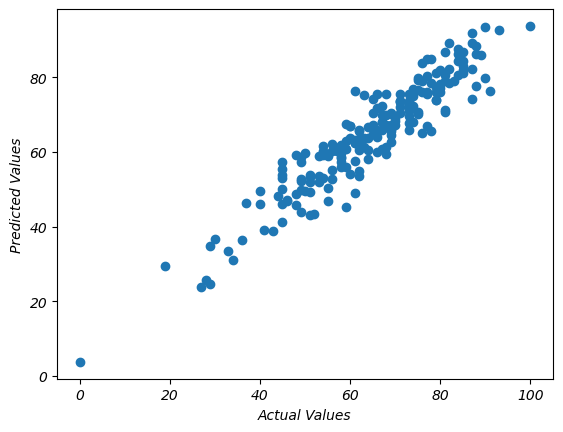

In [40]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

<Axes: xlabel='math_score'>

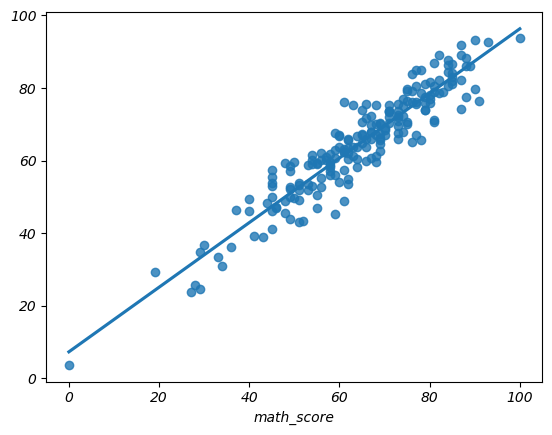

In [43]:
sns.regplot(x=y_test, y=y_pred, ci=None)

### Difference between Actual and Predicted values

In [44]:
pred_df = pd.DataFrame({'Actual Value':y_test, 'Predicted Value':y_pred, 'Difference':y_test-y_pred})
pred_df.head()

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
